In [ ]:
!pip install tensorflow numpy h5py scikit-learn matplotlib

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
zip_path = "/content/drive/MyDrive/ACDC_preprocessed.zip"

In [8]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

In [9]:
import os
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score

In [10]:
# --- Step 1: Data Loading and Preprocessing ---
def load_h5_data(directory, is_training=True, target_size=(256, 256), max_samples=None):
    images, masks = [], []
    sample_count = 0

    for filename in os.listdir(directory):
        if max_samples and sample_count >= max_samples:
            break
        if filename.endswith('.h5'):
            try:
                with h5py.File(os.path.join(directory, filename), 'r') as f:
                    image = f['image'][:]  # Shape: (H, W) or (slices, H, W)
                    if is_training:
                        mask = f['label'][:]  # Shape: (H, W) or (slices, H, W)

                    # Handle 3D volumes (test data) or 2D slices (training data)
                    if image.ndim == 3:  # (slices, H, W)
                        for slice_idx in range(image.shape[0]):
                            slice_img = image[slice_idx]  # (H, W)
                            slice_img = np.expand_dims(slice_img, axis=-1)  # (H, W, 1)
                            slice_img = tf.image.resize(slice_img, target_size, method='bilinear').numpy()
                            images.append(slice_img)
                            if is_training:
                                slice_mask = mask[slice_idx]
                                slice_mask = np.expand_dims(slice_mask, axis=-1)
                                slice_mask = tf.image.resize(slice_mask, target_size, method='nearest').numpy()
                                masks.append(np.squeeze(slice_mask, axis=-1))
                    elif image.ndim == 2:  # (H, W)
                        image = np.expand_dims(image, axis=-1)  # (H, W, 1)
                        image = tf.image.resize(image, target_size, method='bilinear').numpy()
                        images.append(image)
                        if is_training:
                            mask = np.expand_dims(mask, axis=-1)
                            mask = tf.image.resize(mask, target_size, method='nearest').numpy()
                            masks.append(np.squeeze(mask, axis=-1))
                    else:
                        print(f"Unexpected shape in {filename}: {image.shape}")
                        continue

                    sample_count += 1
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                continue

    images = np.array(images)
    masks = np.array(masks) if is_training else None
    return images, masks

# Load training data
# train_dir = '/kaggle/input/acdc-dataset/ACDC_preprocessed/ACDC_training_slices'
# train_dir = '/Users/smt/Documents/FYP/ACDC_preprocessed/ACDC_training_slices'
train_dir = '/content/data/ACDC_preprocessed/ACDC_training_slices'
test_dir = '/content/data/ACDC_preprocessed/ACDC_testing_volumes'
train_images, train_masks = load_h5_data(train_dir, is_training=True, target_size=(256, 256), max_samples=500)

# Normalize images to [0, 1]
train_images = train_images / np.max(train_images)
train_masks = train_masks.astype(np.uint8)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_images, train_masks, test_size=0.2, random_state=42)

# Load test data
# test_dir = '/kaggle/input/acdc-dataset/ACDC_preprocessed/ACDC_testing_volumes'
# test_dir = '/Users/smt/Documents/FYP/ACDC_preprocessed/ACDC_testing_volumes'
test_images, _ = load_h5_data(test_dir, is_training=False, target_size=(256, 256), max_samples=100)

print(f"Training shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {test_images.shape}")

Training shape: (400, 256, 256, 1), Validation shape: (100, 256, 256, 1), Test shape: (1076, 256, 256, 1)


In [11]:
# --- Step 2: Define DUCK-Net Model ---
def duck_net(input_shape, num_classes=4):
    inputs = layers.Input(input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        return x

    # Downsampling path
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    c4 = conv_block(p3, 256)

    # Bottleneck
    bottleneck = conv_block(c4, 512)

    # Upsampling path with skip connections
    u4 = layers.UpSampling2D((2, 2))(bottleneck)
    u4 = layers.Concatenate()([u4, c3])
    c5 = conv_block(u4, 256)
    u3 = layers.UpSampling2D((2, 2))(c5)
    u3 = layers.Concatenate()([u3, c2])
    c6 = conv_block(u3, 128)
    u2 = layers.UpSampling2D((2, 2))(c6)
    u2 = layers.Concatenate()([u2, c1])
    c7 = conv_block(u2, 64)

    # Output layer
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c7)

    model = models.Model(inputs, outputs)
    return model

# Set input shape
input_shape = (256, 256, 1)
model = duck_net(input_shape, num_classes=4)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 7,433,828 (28.36 MB)

 Trainable params: 7,428,068 (28.34 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [12]:
# --- Step 3: Training the Model ---
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 845ms/step - accuracy: 0.7942 - loss: 1.0793 - val_accuracy: 0.0486 - val_loss: 10.4703
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 379ms/step - accuracy: 0.9702 - loss: 0.4767 - val_accuracy: 0.9567 - val_loss: 0.2290
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.9771 - loss: 0.2092 - val_accuracy: 0.9551 - val_loss: 0.2246
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.9805 - loss: 0.1186 - val_accuracy: 0.9590 - val_loss: 0.2127
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.9854 - loss: 0.0719 - val_accuracy: 0.9592 - val_loss: 0.2478
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.9883 - loss: 0.0513 - val_accuracy: 0.9591 - val_loss: 0.2475
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 373ms/step - accuracy: 0.9906 - loss: 0.0390 - val_accuracy: 0.9591 - val_loss: 0.2562
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 373ms/step - accuracy: 0.9915 - loss: 0.0330 - val_acc

In [13]:
model.save_weights("model_weights.weights.h5")

34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 607ms/step
Validation Metrics - Dice: 2.2288, Jaccard: -9.7418, Precision: 0.9516, Recall: 0.9003, Accuracy: 0.9938


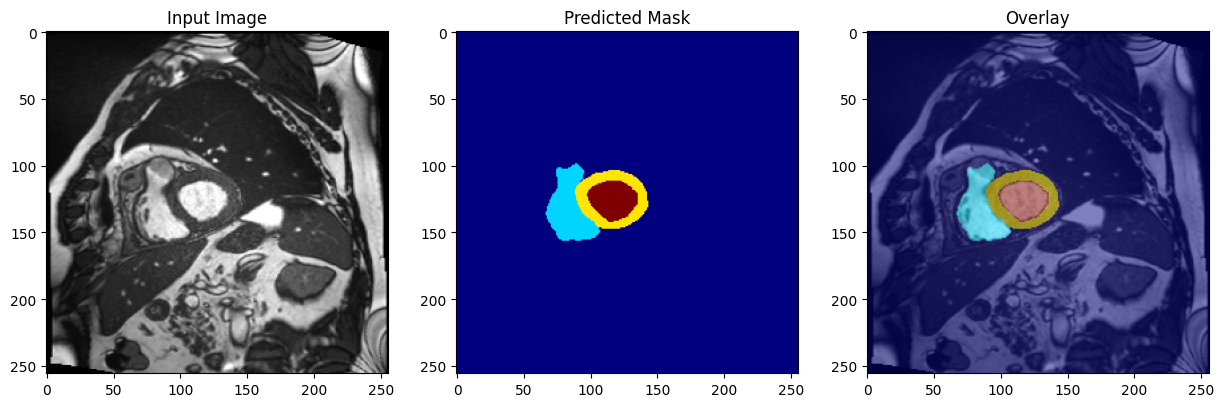

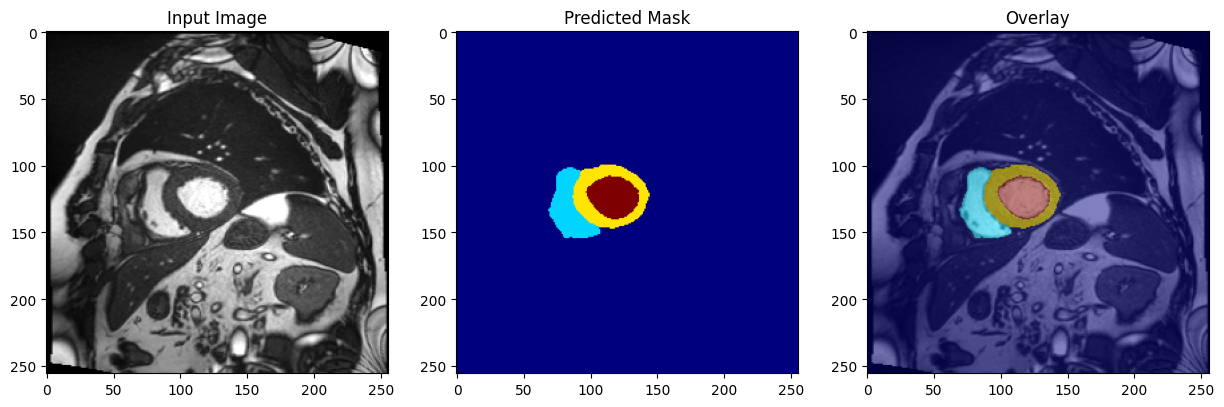

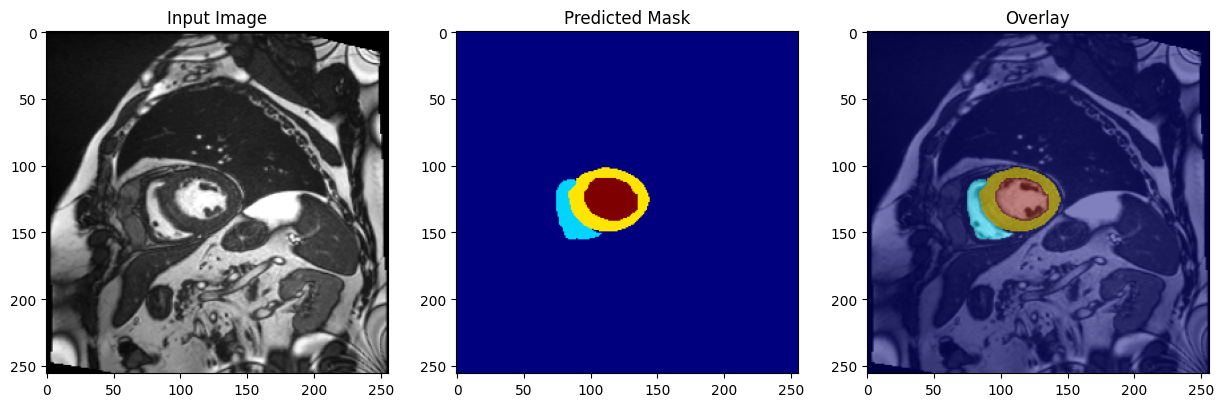

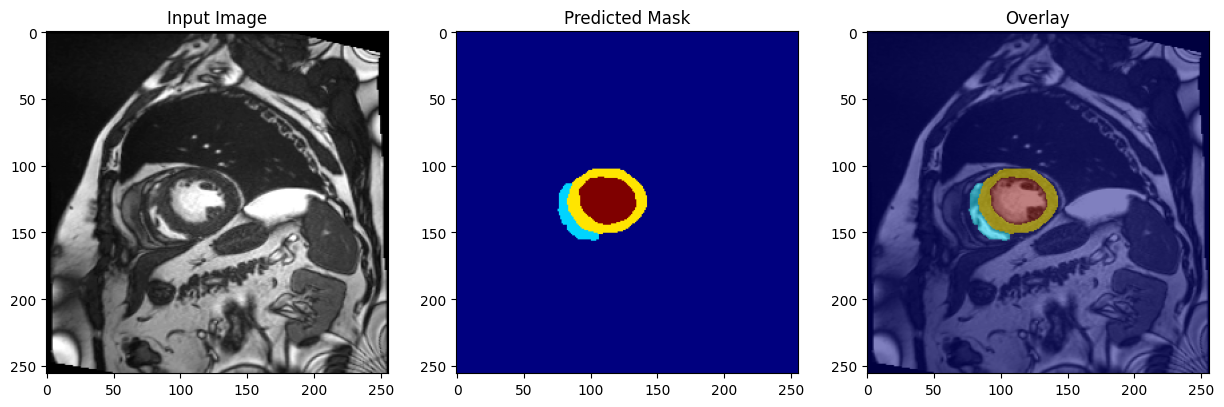

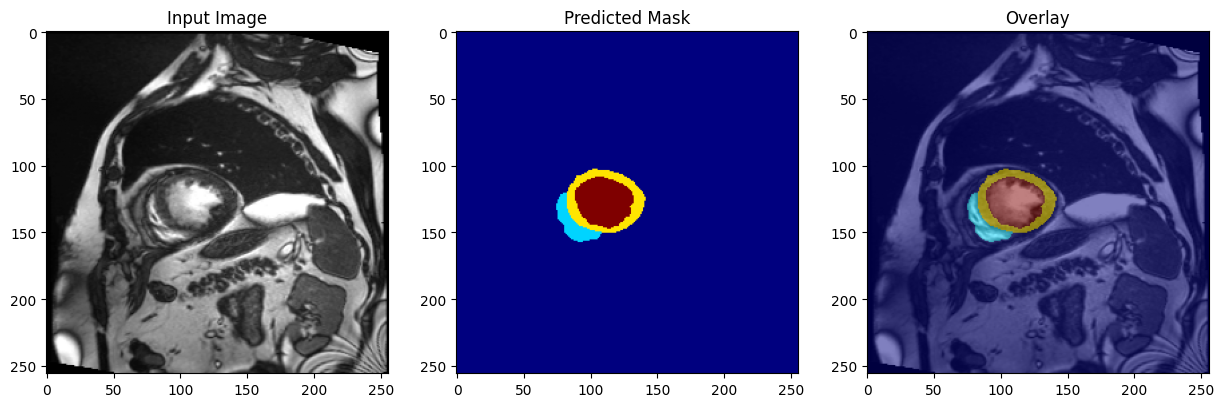

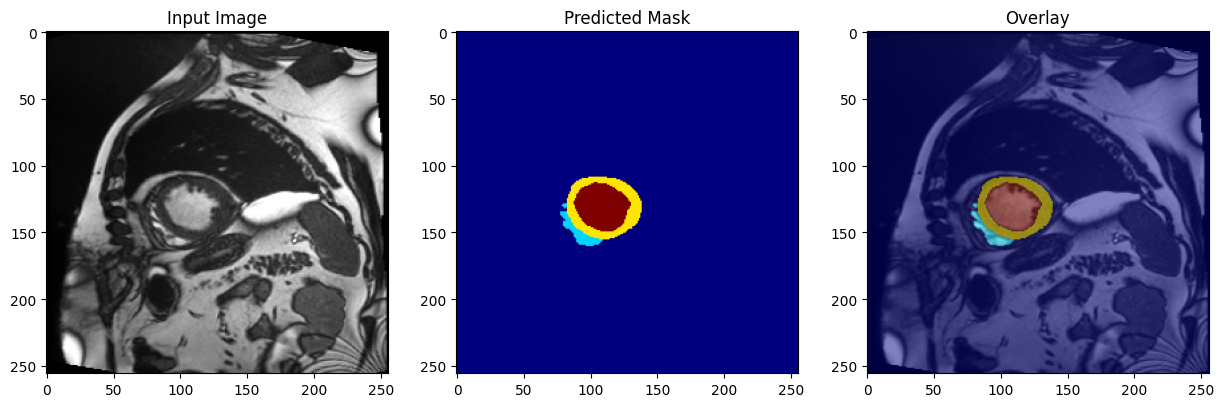

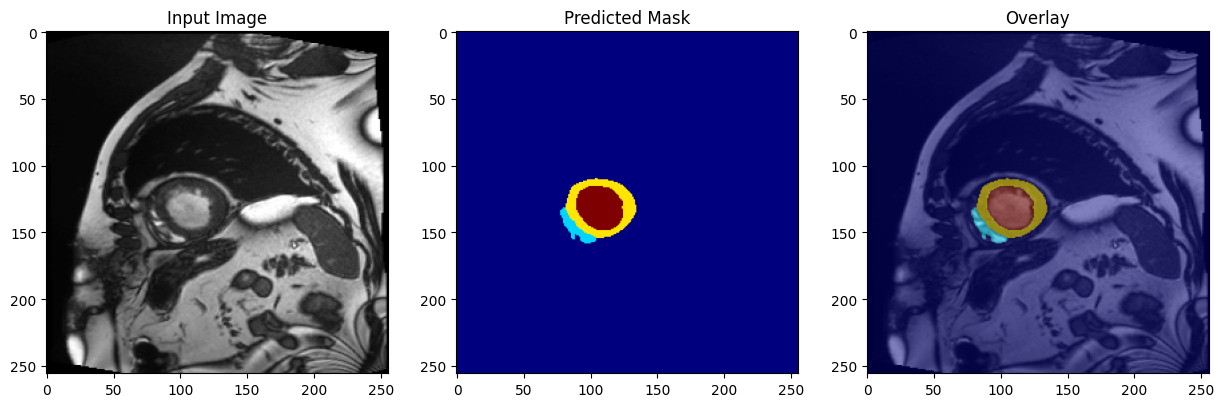

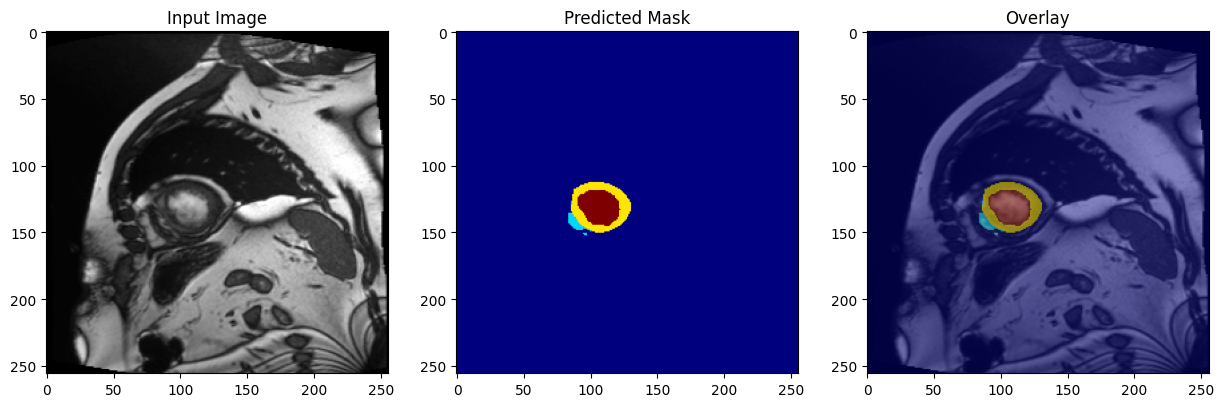

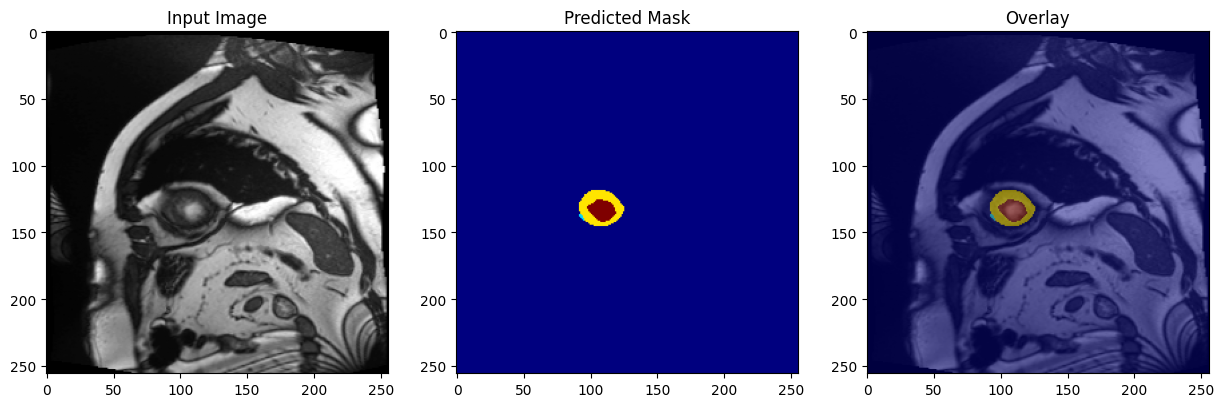

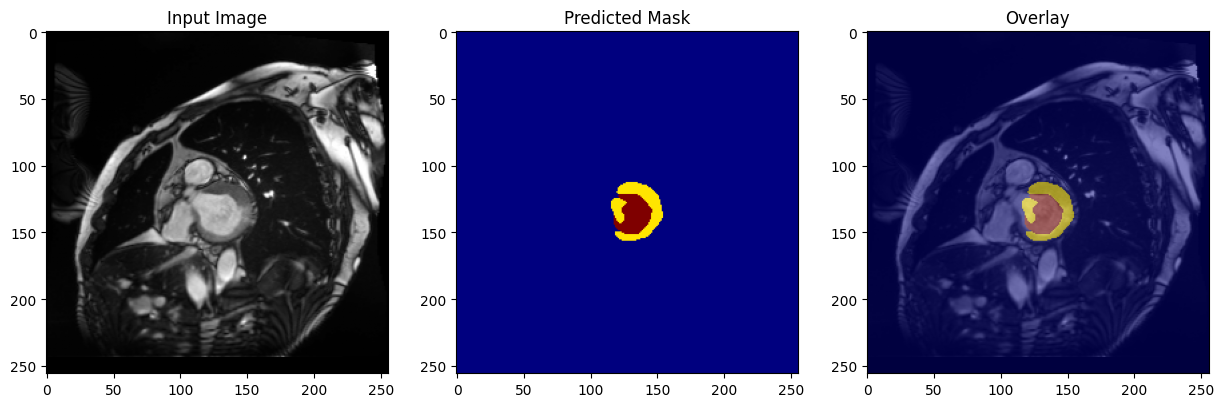

In [14]:
# --- Step 4: Evaluation Metrics ---
def compute_metrics(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = np.argmax(y_pred, axis=-1).flatten()

    dice = 2 * np.sum(y_true_flat * y_pred_flat) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-6)
    jaccard = np.sum(y_true_flat * y_pred_flat) / (np.sum(y_true_flat) + np.sum(y_pred_flat) - np.sum(y_true_flat * y_pred_flat) + 1e-6)
    precision = precision_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true_flat, y_pred_flat)

    return dice, jaccard, precision, recall, accuracy

# Predict on test set
test_preds = model.predict(test_images)

# Compute metrics on validation set
val_preds = model.predict(X_val)
dice, jaccard, precision, recall, accuracy = compute_metrics(y_val, val_preds)
print(f"Validation Metrics - Dice: {dice:.4f}, Jaccard: {jaccard:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}")

# Visualization of test predictions
for i in range(10):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(test_images[i, :, :, 0], cmap='gray')
    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(np.argmax(test_preds[i], axis=-1), cmap='jet')
    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(test_images[i, :, :, 0], cmap='gray')
    plt.imshow(np.argmax(test_preds[i], axis=-1), cmap='jet', alpha=0.5)
    plt.show()

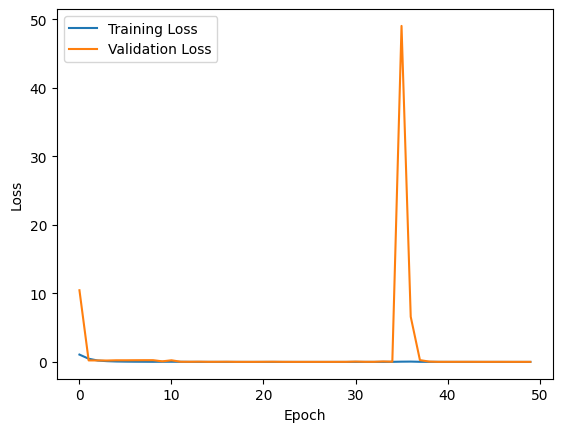

In [15]:
# --- Step 5: Plot Training History ---
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()